In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt
import pandas as pd
import numpy as np

ModuleNotFoundError: No module named 'altair'

In [ ]:
df = pd.read_csv('music_streams.csv')
sns.set_theme(style="darkgrid")

In [ ]:
df.columns


Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='object')

In [ ]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


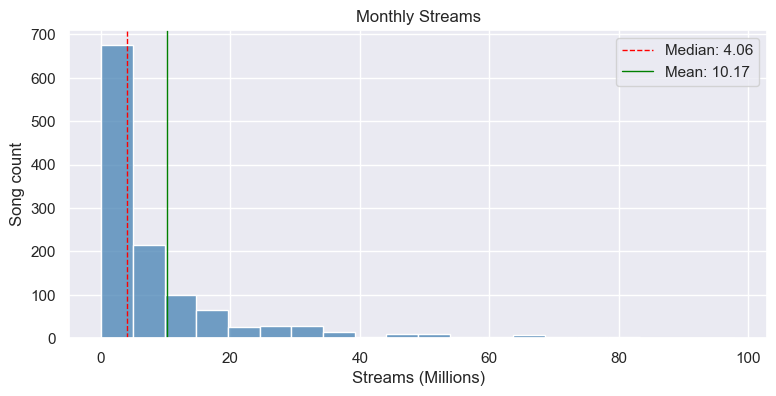

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
median = df.streams_millions.median()
mean = df.streams_millions.mean()
sns.histplot(data=df[df.streams_millions < 100], x='streams_millions', bins=20, ax=ax, color="steelblue")
ax.axvline(median, color='red', linestyle='dashed', linewidth=1, label=f'Median: {median:.2f}')
ax.axvline(mean, color='green', linestyle='solid', linewidth=1, label=f'Mean: {mean:.2f}')
ax.set_title('Monthly Streams')
ax.set_xlabel('Streams (Millions)')
ax.set_ylabel('Song count')
ax.legend()
plt.show()

In [ ]:
def create_histogram(column_name, title, x_label, max_val=None, xlim=None):
    fig, ax = plt.subplots(figsize=(9, 4))
    data = df[df[column_name] < max_val] if max_val is not None else df
    median = df[column_name].median()
    mean = df[column_name].mean()
    sns.histplot(data=data, x=column_name, bins=20, ax=ax, color="steelblue")
    ax.axvline(median, color='orange', linestyle='dashed', linewidth=1, label=f'Median')
    ax.axvline(mean, color='blue', linestyle='solid', linewidth=1, label=f'Mean')
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Song count')
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.legend()
    plt.show()

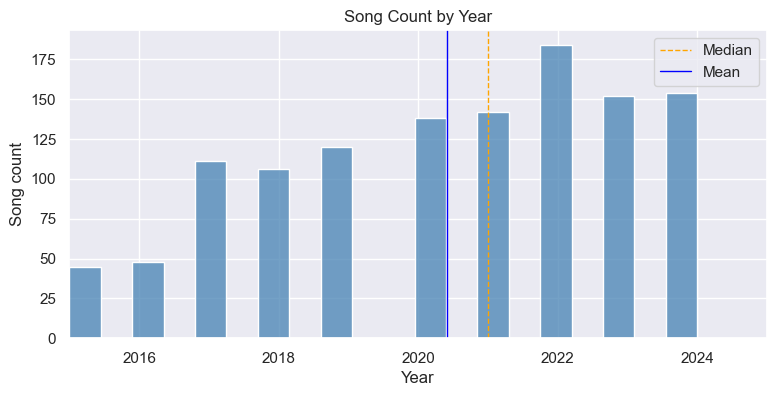

In [ ]:
create_histogram('year', 'Song Count by Year', 'Year', xlim=(2015, 2025))


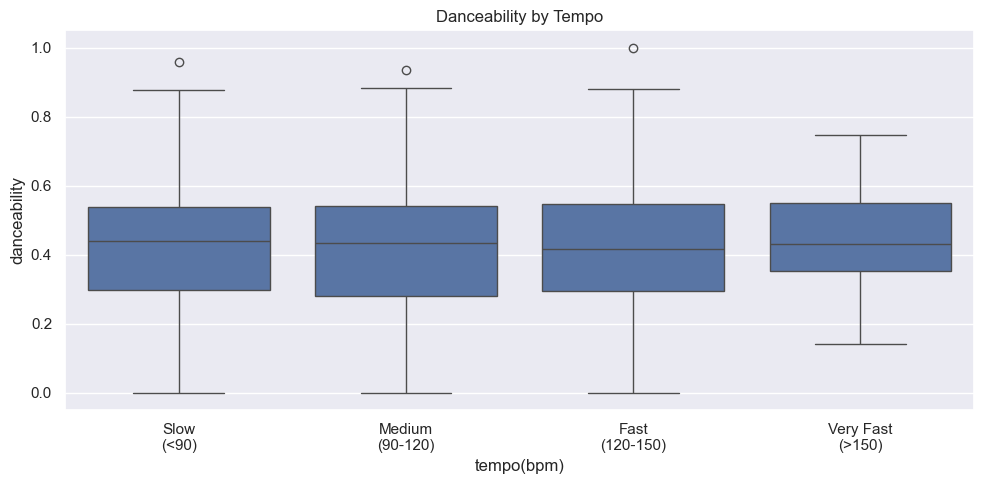

In [ ]:
df['tempo_category'] = pd.cut(df['tempo_bpm'], bins=[0, 90, 120, 150, 200], labels=['Slow\n(<90)', 'Medium\n(90-120)', 'Fast\n(120-150)', 'Very Fast\n(>150)'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='tempo_category', y='danceability', ax=ax)
ax.set_title('Danceability by Tempo')
ax.set_xlabel('tempo(bpm)')
ax.set_ylabel('danceability')
plt.tight_layout()
plt.show()

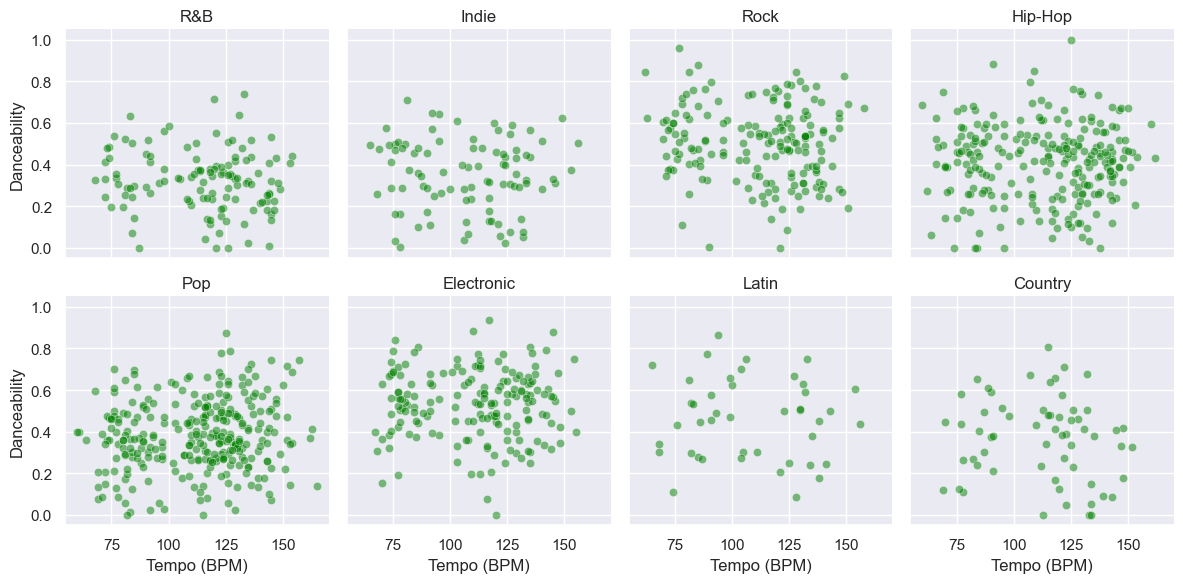

In [ ]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "tempo_bpm", "danceability", color="green", alpha=0.5)
g.set_axis_labels("Tempo (BPM)", "Danceability")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

In [ ]:
pop_trend = df[df['genre'] == 'Pop'].groupby('year')['streams_millions'].median()
pop_trend

year
2015     7.160
2016     3.540
2017     3.560
2018    11.370
2019     4.720
2020     5.075
2021     3.645
2022     4.445
2023     4.230
2024     3.390
Name: streams_millions, dtype: float64

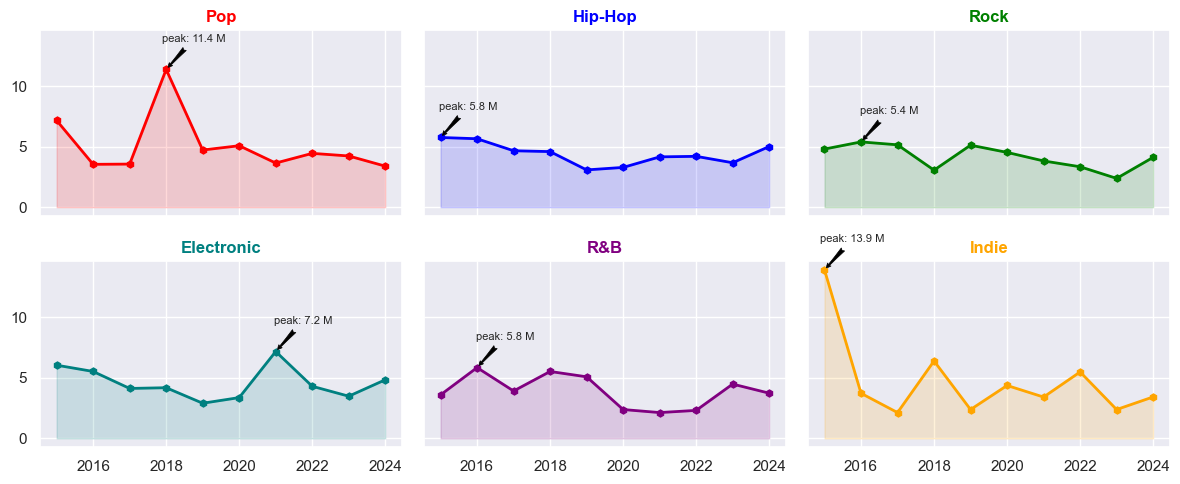

In [ ]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B","Indie"]
colors = ["red", "blue", "green", "teal", "purple", "orange"]

trend = df[df.genre.isin(genres)].groupby(["year","genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2,3,figsize=(12,5),sharex=True,sharey=True)
axes = axes.flatten()

for ax, genre, color in zip(axes, genres, colors):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.streams_millions, marker="h", ms=5, color=color, linewidth=2)
    ax.fill_between(subD.year, subD.streams_millions, alpha=0.15, color=color)
    peak = subD.loc[subD.streams_millions.idxmax()]
    ax.annotate(f"peak: {peak.streams_millions:.1f} M", xy=(peak.year,peak.streams_millions),
                xytext=(20,20), textcoords="offset points", ha="center", fontsize=8, arrowprops=dict(arrowstyle="fancy", color="black", lw=0.5))
    ax.set_title(genre, fontweight="bold", color=color)

plt.tight_layout()
plt.show()

In [ ]:

grouped = df.groupby("genre")[["energy", "danceability"]].mean().reset_index()
melted = grouped.melt(id_vars="genre", var_name="Metric", value_name="Value")

alt.Chart(melted).mark_bar().encode(
    x=alt.X("genre:N", title="Genre"),
    y=alt.Y("Value:Q", title="Mean Value"),
    xOffset="Metric:N",
    color="Metric:N"
).properties(
    title="Energy vs Danceability by Genre",
    width=500,
    height=300
)